<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Adding white noise channels or all-zeros channels to MNIST
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax")
        ]
    )

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8674 - loss: 0.4378 - val_accuracy: 0.9118 - val_loss: 0.2949
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9302 - loss: 0.2334 - val_accuracy: 0.9319 - val_loss: 0.2310
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9549 - loss: 0.1531 - val_accuracy: 0.9493 - val_loss: 0.1698
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9680 - loss: 0.1093 - val_accuracy: 0.9582 - val_loss: 0.1424
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9784 - loss: 0.0758 - val_accuracy: 0.9568 - val_loss: 0.1455
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9846 - loss: 0.0538 - val_accuracy: 0.9569 - val_loss: 0.1457
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9884 - loss: 0.0407 - val_accuracy: 0.9590 - val_loss: 0.1414
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9924 - loss: 0.0283 - val_a

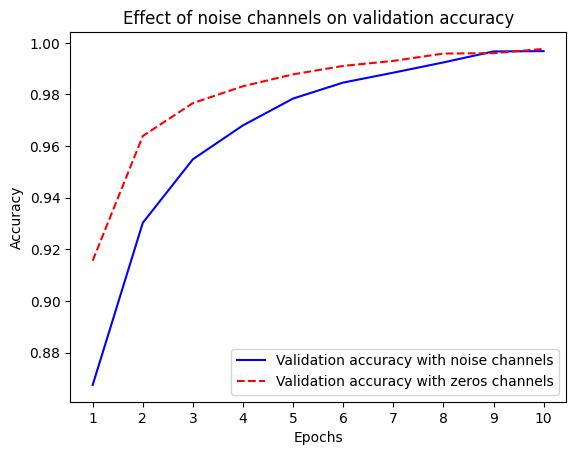

In [3]:
import matplotlib.pyplot as plt

acc_noise = history_noise.history["accuracy"]
acc_zeros = history_zeros.history["accuracy"]
epochs = range(1, len(acc_noise) + 1)


# b" is for "solid blue line."
plt.plot(epochs, acc_noise, "b", label="Validation accuracy with noise channels")

# "r--" is for "dashed red line."
plt.plot(epochs, acc_zeros, "r--", label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)

plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [4]:
# Fitting an MNIST model with randomly shuffled labels
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

# Copies train_labels
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_random = model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1028 - loss: 2.3156 - val_accuracy: 0.1046 - val_loss: 2.3038
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1168 - loss: 2.2993 - val_accuracy: 0.1013 - val_loss: 2.3080
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1273 - loss: 2.2915 - val_accuracy: 0.0970 - val_loss: 2.3166
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1373 - loss: 2.2805 - val_accuracy: 0.1017 - val_loss: 2.3255
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.1513 - loss: 2.2648 - val_accuracy: 0.1002 - val_loss: 2.3350
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1654 - loss: 2.2449 - val_accuracy: 0.1039 - val_loss: 2.3471
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1777 - loss: 2.2220 - val_accuracy: 0.1058 - val_loss: 2.3603
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1969 - loss: 2.1931 - 

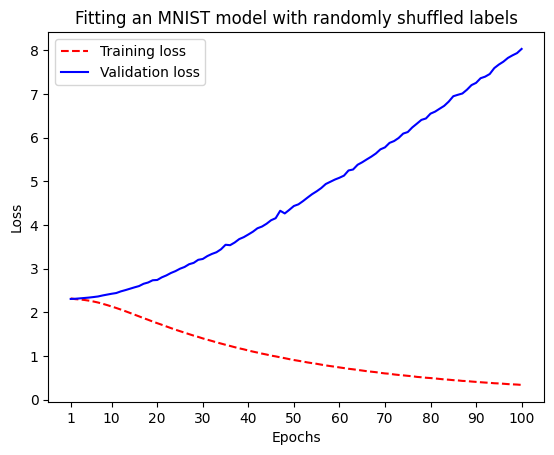

In [5]:
# Clears the figure
plt.clf()

history_dict = history_random.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

# "r--" is for "dashed red line."
plt.plot(epochs, loss_values, "r--", label="Training loss")

# b" is for "solid blue line."
plt.plot(epochs, val_loss_values, "b", label="Validation loss")

plt.title("Fitting an MNIST model with randomly shuffled labels")
plt.xlabel("Epochs")
plt.xticks([1, *range(10, 101, 10)])

plt.ylabel("Loss")
plt.legend()

plt.show()

In [6]:
# Evaluating machine-learning models

In [7]:
# Improving model fit

In [8]:
# Improving generalization